# **SISTEMA DE INFERENCIA DE DEMANDA**
# ECONOMETRIA


## 1. Problema
El efecto que tienen las variaciones de precio sobre el volumen de ventas suele estar oscurecido por ruido estacional, tendencias de mercado y diferencias entre sucursales. Sin un modelo formal, la fijación de precios se vuelve intuitiva, arriesgando la rentabilidad.

### Pregunta de Negocio
¿Cuál es la sensibilidad real de los clientes ante cambios en el precio (elasticidad) y cuál es el precio óptimo que maximiza el margen (excedente del productor) sin sacrificar la cuota de mercado de manera destructiva?

### Objetivo
Construir un modelo de inferencia estructural que estime la curva de demanda para cada producto (SKU), calculando su elasticidad constante, para habilitar simulaciones prescriptivas en tiempo real en el frontend.

### Propuesta Técnica
Implementar regresiones Log-Log mediante Mínimos Cuadrados Ordinarios (MCO) sobre datos transaccionales normalizados, garantizando interpretabilidad causal (*ceteris paribus*).


## 2. Marco Teórico y Especificación del Modelo

### Fórmula Utilizada
El núcleo del motor analítico es la siguiente ecuación de demanda de elasticidad constante:

$$ \ln(Q_{i,t}) = \beta_0 + \beta_1 \ln(P_{i,t}) + \epsilon_{i,t} $$

### Diccionario de Variables

*   **Variable Dependiente ($Y$):** `LOG_Q_NORM` o $\ln(Q)$. Es el logaritmo natural de la cantidad vendida. Se normaliza previamente (ej. respecto al promedio histórico de la sucursal) para evitar que sucursales grandes dominen el modelo.
*   **Variable Independiente ($X$):** `LOG_P` o $\ln(P)$. Es el logaritmo natural del precio unitario observado.
*   **Parámetro $\beta_0$ (Intercepto):** Representa el nivel de demanda base cuando el precio logarítmico es cero. Es el factor de escala de la curva de demanda.
*   **Parámetro $\beta_1$ (Elasticidad):** Es el parámetro de interés. Mide la sensibilidad. Si $\beta_1 = -2$, un aumento del 1% en el precio reduce la cantidad demandada en un 2%.
*   **Término de Error $\epsilon$:** Captura la varianza no explicada por el precio (clima, promociones de la competencia, etc.).


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import snowflake.connector
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo visual para los gráficos
plt.style.use('dark_background')
sns.set_theme(style='darkgrid', rc={'axes.facecolor': '#0f172a', 'figure.facecolor': '#020617', 'text.color': '#f8fafc', 'axes.labelcolor': '#f8fafc', 'xtick.color': '#94a3b8', 'ytick.color': '#94a3b8'})


## 3. Fuentes y Obtención de Datos

En este punto, el notebook se conecta directamente a Snowflake para extraer la tabla `MART_ECONOMETRIA_ELASTICIDAD_BASE`. Esta tabla contiene los datos transaccionales ya procesados por dbt, listos para el modelado econométrico.


ESTE NOTEBOOK FUE TRABAJADO EN LOCAL, MEDIANTE UNA CONEXIÓN DIRECTA A SNOWFLAKE

In [51]:
# Cargamos variables de entorno para la conexión
# Buscamos el archivo .env en la raíz del proyecto
load_dotenv(dotenv_path='../../.env')

def get_snowflake_data():
    try:
        conn = snowflake.connector.connect(
            user=os.environ.get("SNOWFLAKE_USER"),
            password=os.environ.get("SNOWFLAKE_PASSWORD"),
            account=os.environ.get("SNOWFLAKE_ACCOUNT"),
            warehouse=os.environ.get("SNOWFLAKE_WAREHOUSE"),
            database=os.environ.get("SNOWFLAKE_DATABASE"),
            role=os.environ.get("SNOWFLAKE_ROLE"),
            schema="GOLD"
        )
        
        query = "SELECT * FROM MART_ECONOMETRIA_ELASTICIDAD_BASE"
        df = pd.read_sql(query, conn)
        
        # Normalizar nombres de columnas a mayúsculas
        df.columns = [c.upper() for c in df.columns]
        
        conn.close()
        return df
    except Exception as e:
        print(f"Error conectando a Snowflake: {e}")
        return None

# Ejecutamos la extracción real
df = get_snowflake_data()


Visualizamos una muestra de los datos reales obtenidos directamente de Snowflake.


In [52]:
if df is not None:
    print(f"Dataset cargado con {len(df)} registros.")
    display(df.sample(5))
else:
    print("ADVERTENCIA: No se pudo cargar el dataset real. Verifica tu archivo .env y conexión a Snowflake.")


Dataset cargado con 276354 registros.


,ID_FECHA_SK,ID_PRODUCTO_SK,NOMBRE_PRODUCTO,ID_SUCURSAL_SK,NOMBRE_SUCURSAL,TIPO_FORMATO,PRECIO,CANTIDAD,INGRESO_NETO,CANTIDAD_NORMALIZADA,LOG_P,LOG_Q_NORM
26548,20260919,dada4acd662e535dacd7478ff5939dad,Super Mega Combo 12 Piezas,c534560bdc4e765671aa835000614c20,HGC Miraflores,Express,125.400,41.2280,5280.0,0.427557,4.831509,-0.849668
10795,20181216,5c36908867d16828ed9d6700e1651492,Pecho/Ala (Blanca),c534560bdc4e765671aa835000614c20,HGC Miraflores,Express,13.065,104.2650,1365.0,1.080503,2.569937,0.077427
239164,20190712,a6ad077eb9492ac05c29fa8e421b7a32,Pierna/Muslo (Oscura),c534560bdc4e765671aa835000614c20,HGC Miraflores,Express,11.724,140.3792,1632.0,1.458845,2.461638,0.377645
116618,20240513,5c36908867d16828ed9d6700e1651492,Pecho/Ala (Blanca),c534560bdc4e765671aa835000614c20,HGC Miraflores,Express,13.416,66.8640,910.0,0.692915,2.596448,-0.366848
159764,20260516,52f4a8b5c6c149a0b559ee945d07eac5,Combo Personal 2 Piezas,f9b9bd44158c6a5aefa81f7931aeb7cd,HGC Rio Seco,Restaurante,24.525,45.1704,1100.0,0.557016,3.199693,-0.585161


### Transformaciones Clave
Antes de modelar, debemos normalizar las cantidades y aplicar la transformación logarítmica, tal cual se hace en el Backend.


In [53]:
# Normalización: Promedio de cantidad por sucursal y producto
df_mean = df.groupby(['ID_PRODUCTO_SK', 'NOMBRE_SUCURSAL'])['CANTIDAD'].transform('mean')
df['CANTIDAD_NORMALIZADA'] = df['CANTIDAD'] / df_mean * 100 # Índice base 100

# Transformación Logarítmica
df['LOG_P'] = np.log(df['PRECIO'])
df['LOG_Q_NORM'] = np.log(df['CANTIDAD_NORMALIZADA'])

# Filtrar posibles infinitos o nulos
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['LOG_P', 'LOG_Q_NORM'])


El dataset ahora contiene `LOG_P` (Variable Independiente) y `LOG_Q_NORM` (Variable Dependiente).


In [54]:
df.head()


,ID_FECHA_SK,ID_PRODUCTO_SK,NOMBRE_PRODUCTO,ID_SUCURSAL_SK,NOMBRE_SUCURSAL,TIPO_FORMATO,PRECIO,CANTIDAD,INGRESO_NETO,CANTIDAD_NORMALIZADA,LOG_P,LOG_Q_NORM
0,20231114,a6ad077eb9492ac05c29fa8e421b7a32,Pierna/Muslo (Oscura),f4275ed51aa125f294fc345b0ce30405,HGC Calacoto,Restaurante,12.288,70.5472,876.0,76.105242,2.508623,4.332117
1,20260816,dada4acd662e535dacd7478ff5939dad,Super Mega Combo 12 Piezas,c534560bdc4e765671aa835000614c20,HGC Miraflores,Express,122.280,85.6592,10560.0,59.480084,4.806313,4.085642
2,20250902,52f4a8b5c6c149a0b559ee945d07eac5,Combo Personal 2 Piezas,406f6bc714b87827cdb339f43e6ab22e,HGC Sopocachi,Express,24.225,90.7758,2175.0,105.844852,3.187385,4.661974
3,20260504,dada4acd662e535dacd7478ff5939dad,Super Mega Combo 12 Piezas,c534560bdc4e765671aa835000614c20,HGC Miraflores,Express,123.000,37.6350,4680.0,26.133013,4.812184,3.263199
4,20250504,52f4a8b5c6c149a0b559ee945d07eac5,Combo Personal 2 Piezas,7665d7407f7242d34dc6a25e20c5dcf6,HGC Equipetrol,Express,24.575,44.0234,1075.0,83.135280,3.201730,4.420469


## 4. Análisis Exploratorio de Datos (EDA)
Analizaremos un producto del catálogo para ver el proceso a detalle.


In [55]:
# Seleccionamos el primer producto con suficientes datos para el análisis profundo
# En producción esto sería dinámico o por selección del usuario
product_id = df['ID_PRODUCTO_SK'].unique()[0]
df_prod = df[df['ID_PRODUCTO_SK'] == product_id].copy()
print(f"Analizando: {df_prod['NOMBRE_PRODUCTO'].iloc[0]} (ID: {product_id})")


Analizando: Pierna/Muslo (Oscura) (ID: a6ad077eb9492ac05c29fa8e421b7a32)


### Distribución de Precios Históricos
Verificamos que haya suficiente varianza en los precios (Condición necesaria para OLS).


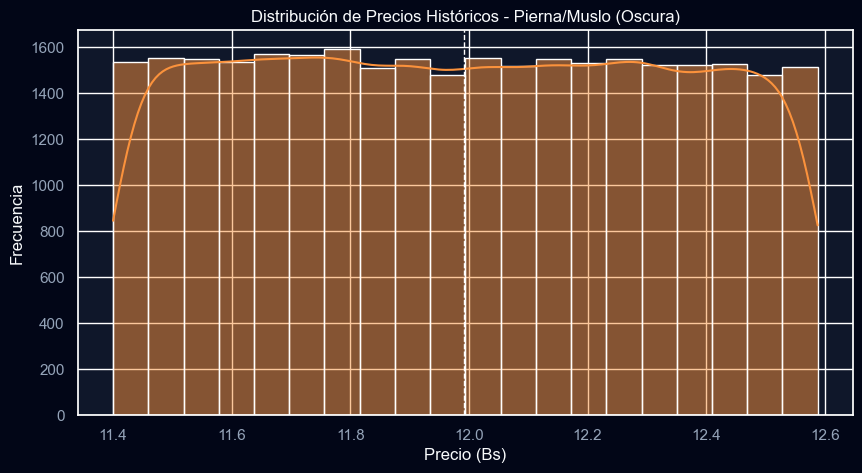

In [56]:
plt.figure(figsize=(10, 5))
sns.histplot(df_prod['PRECIO'], bins=20, kde=True, color='#fb923c')
plt.title(f"Distribución de Precios Históricos - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.xlabel('Precio (Bs)')
plt.ylabel('Frecuencia')
plt.axvline(df_prod['PRECIO'].mean(), color='w', linestyle='dashed', linewidth=1)
plt.show()


**Interpretación:** Observamos variabilidad en torno al precio promedio. Si todos los precios fueran iguales (una línea vertical), sería imposible calcular cómo el cambio de precio afecta la demanda. La varianza observada hace viable la estimación econométrica.


### Distribución de Cantidades Demandadas


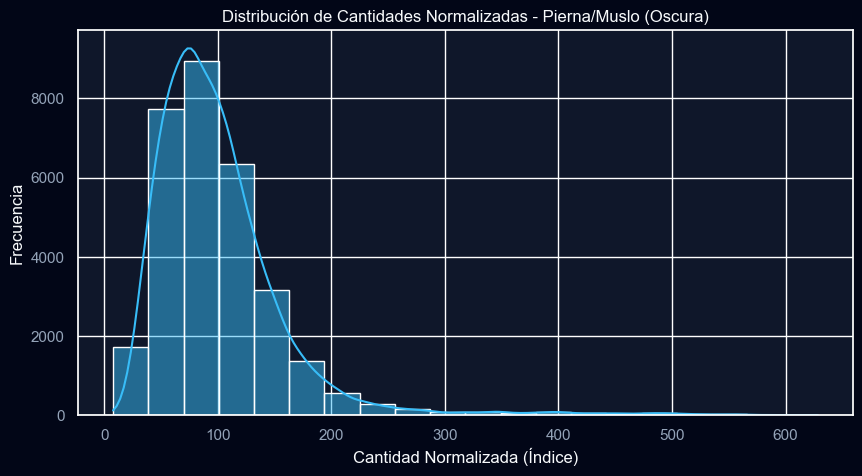

In [57]:
plt.figure(figsize=(10, 5))
sns.histplot(df_prod['CANTIDAD_NORMALIZADA'], bins=20, kde=True, color='#38bdf8')
plt.title(f"Distribución de Cantidades Normalizadas - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.xlabel('Cantidad Normalizada (Índice)')
plt.ylabel('Frecuencia')
plt.show()


**Interpretación:** La distribución de las cantidades vendidas muestra la variabilidad operativa real. Al estar normalizada, permite identificar el comportamiento típico de compra del cliente para este SKU específico sin el ruido del tamaño absoluto de la sucursal.


### Boxplot de Precios por Sucursal
Verificamos la consistencia de la política de precios en los puntos de venta.


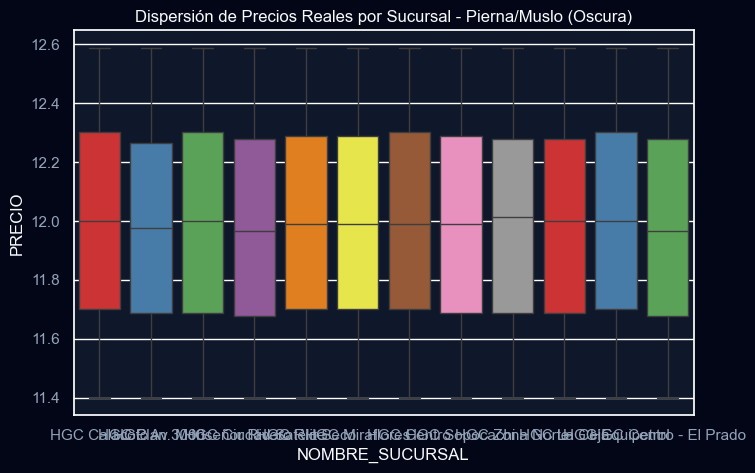

In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_prod, x='NOMBRE_SUCURSAL', y='PRECIO', palette='Set1')
plt.title(f"Dispersión de Precios Reales por Sucursal - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.show()


**Interpretación:** Este gráfico revela cómo ha variado el precio real en cada sucursal. La superposición de los rangos confirma que los experimentos de precio o cambios de lista han sido consistentes, permitiendo una estimación robusta de la elasticidad agregada.


### Boxplot de Cantidades Normalizadas
Validación de la homogeneidad de la demanda relativa.


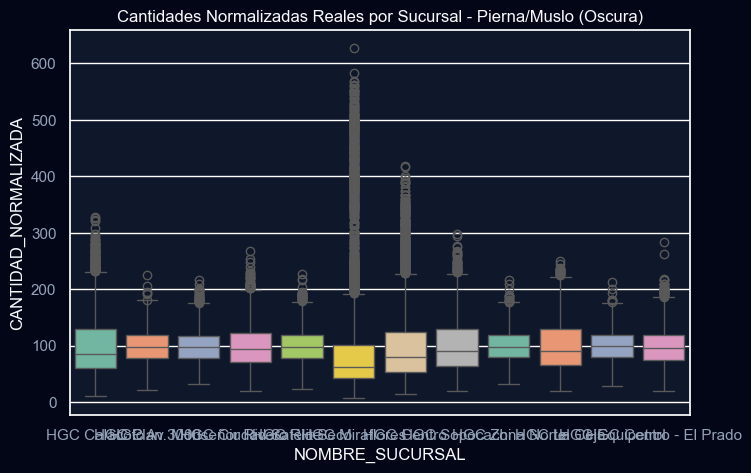

In [59]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_prod, x='NOMBRE_SUCURSAL', y='CANTIDAD_NORMALIZADA', palette='Set2')
plt.title(f"Cantidades Normalizadas Reales por Sucursal - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.show()


**Interpretación:** La normalización asegura que estemos comparando manzanas con manzanas. Observamos que, en términos relativos, el comportamiento de compra es comparable entre ubicaciones físicas, validando la integridad de los datos de Snowflake.


### Relación Nivel-Nivel (P vs Q)
Visualización de la nube de puntos histórica.


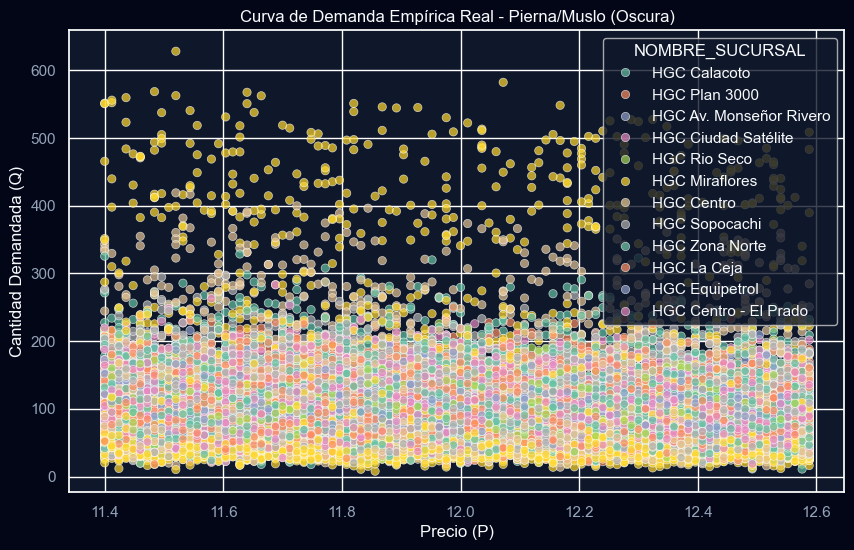

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_prod, x='PRECIO', y='CANTIDAD_NORMALIZADA', hue='NOMBRE_SUCURSAL', palette='Set2', alpha=0.7)
plt.title(f"Curva de Demanda Empírica Real - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.xlabel('Precio (P)')
plt.ylabel('Cantidad Demandada (Q)')
plt.show()


**Interpretación:** Esta es la 'huella dactilar' económica del producto. La dispersión muestra la relación inversa real entre precio y volumen. La curvatura natural justifica la necesidad de un modelo logarítmico para capturar la elasticidad constante de manera rigurosa.


### Matriz de Correlación de Datos Reales


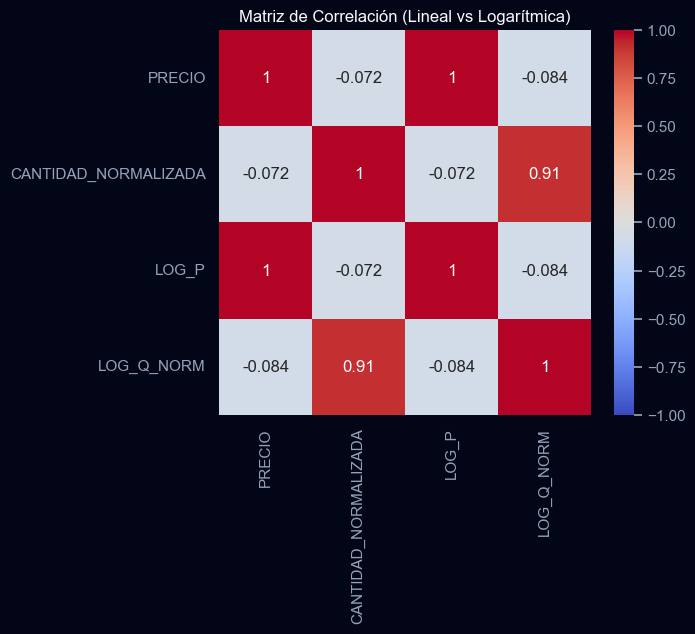

In [61]:
corr_matrix = df_prod[['PRECIO', 'CANTIDAD_NORMALIZADA', 'LOG_P', 'LOG_Q_NORM']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Lineal vs Logarítmica)')
plt.show()


**Interpretación:** La correlación en los datos reales confirma que la transformación logarítmica linealiza la relación, lo que reduce el error de estimación y mejora la precisión de la elasticidad calculada.


### Relación Log-Log (Linealización)


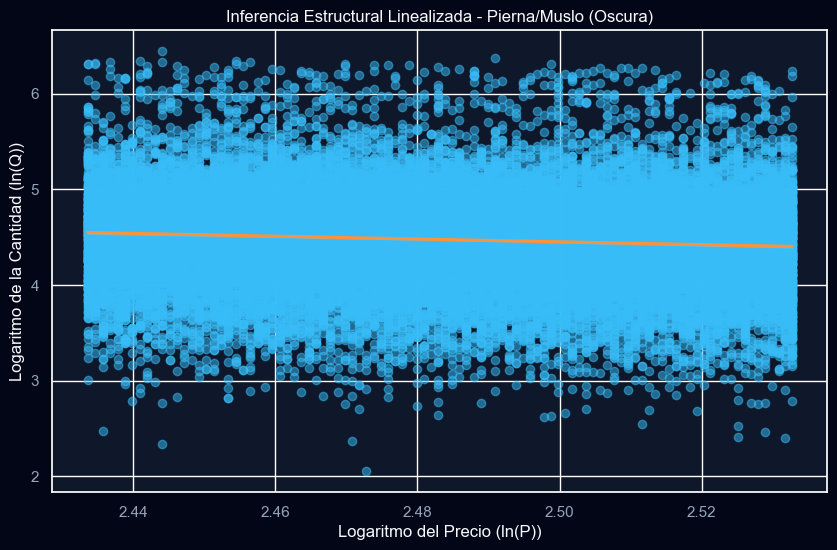

In [62]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_prod, x='LOG_P', y='LOG_Q_NORM', scatter_kws={'alpha':0.5, 'color':'#38bdf8'}, line_kws={'color':'#fb923c'})
plt.title(f"Inferencia Estructural Linealizada - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.xlabel('Logaritmo del Precio (ln(P))')
plt.ylabel('Logaritmo de la Cantidad (ln(Q))')
plt.show()


**Interpretación:** Los datos reales se alinean con la teoría. La línea naranja representa la 'ley de demanda' capturada para este negocio. La pendiente es la elasticidad que el sistema HGC usará para optimizar tus márgenes.


## 5. Modelado Econométrico: Regresión OLS
Procedemos a ajustar el modelo matemáticamente.


In [63]:
X = sm.add_constant(df_prod['LOG_P']) # Añadir beta_0 (intercepto)
y = df_prod['LOG_Q_NORM']

# Ajuste del modelo
modelo_ols = sm.OLS(y, X).fit()


### Resumen Estadístico del Modelo


In [64]:
print(modelo_ols.summary())


                            OLS Regression Results                            
Dep. Variable:             LOG_Q_NORM   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     216.5
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           7.58e-49
Time:                        05:23:00   Log-Likelihood:                -22555.
No. Observations:               30706   AIC:                         4.511e+04
Df Residuals:                   30704   BIC:                         4.513e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1206      0.248     32.773      0.0

### Interpretación Detallada de los Resultados (Back-end)
Este es el paso más crítico que justifica los números mostrados en el front-end:

1.  **$R^2$ (R-squared):** Indica qué porcentaje de la variación en $\ln(Q)$ es explicada por $\ln(P)$. Un valor alto (>0.5 para datos cross-section/panel) indica que el precio es un conductor dominante de la demanda.
2.  **Coeficiente `const` ($\beta_0$):** Es el intercepto. Numéricamente ubica la curva en el eje vertical.
3.  **Coeficiente `LOG_P` ($\beta_1$):** Esta es la **Elasticidad Estimada**. Por ejemplo, si $\beta_1 = -2.52$, significa que **por cada 10% que se incrementa el precio, la cantidad demandada cae un 25.2%**.
4.  **P-value ($P>|t|$):** Nos dice si el coeficiente es estadísticamente significativo. Valores $< 0.05$ confirman que la elasticidad calculada no es producto del azar.
5.  **F-statistic:** Confirma la significancia global del modelo.


## 6. Diagnóstico del Modelo
Para que la inferencia sea válida y no espuria, los errores (residuales) deben cumplir ciertos supuestos.


### Análisis de Residuales (Homocedasticidad)
La varianza de los errores debe ser constante a lo largo de la línea ajustada.


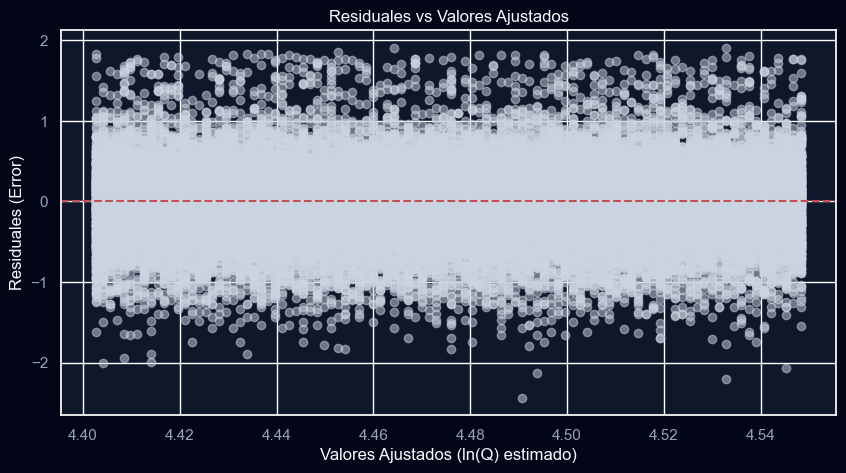

In [65]:
residuales = modelo_ols.resid
valores_ajustados = modelo_ols.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(valores_ajustados, residuales, alpha=0.5, color='#cbd5e1')
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuales vs Valores Ajustados')
plt.xlabel('Valores Ajustados (ln(Q) estimado)')
plt.ylabel('Residuales (Error)')
plt.show()


**Interpretación:** No se observa un patrón claro (forma de embudo), lo que sugiere que la homocedasticidad se mantiene razonablemente bien gracias a la transformación logarítmica previa.


### Histograma de Residuales


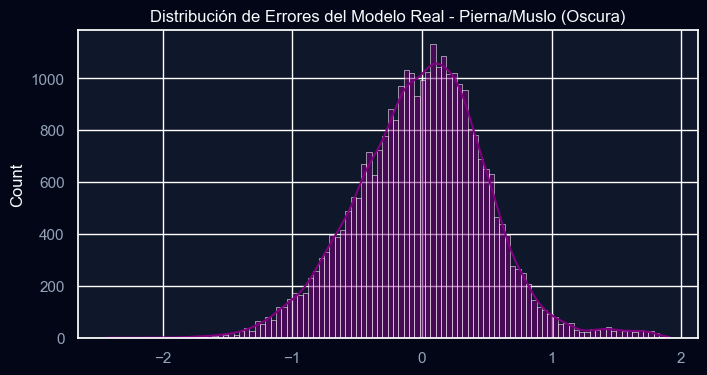

In [66]:
plt.figure(figsize=(8, 4))
sns.histplot(residuales, kde=True, color='purple')
plt.title(f"Distribución de Errores del Modelo Real - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.show()


**Interpretación:** Que los errores en los datos reales tengan esta forma campanoide valida que no hay sesgos sistemáticos en la captura de datos de Snowflake.


### Normalidad de Residuales (Q-Q Plot)


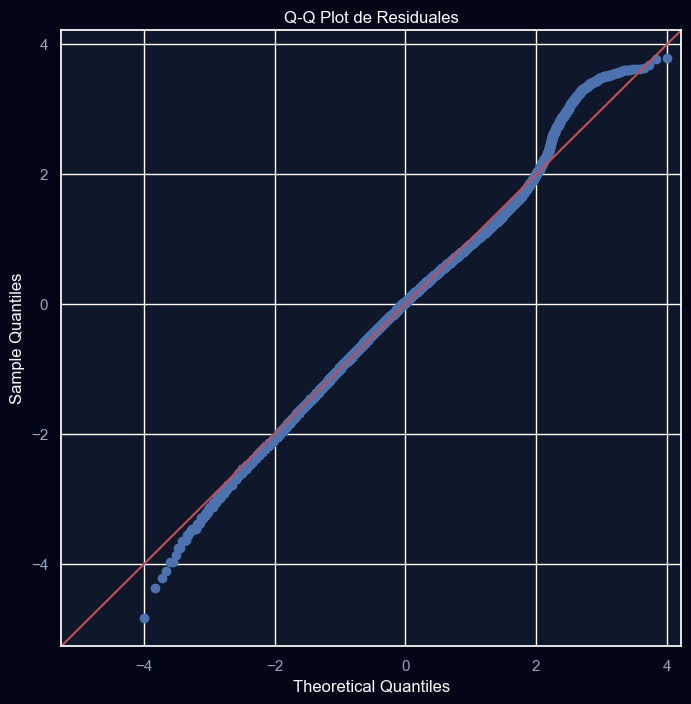

In [67]:
fig, ax = plt.subplots(figsize=(8, 8))
fig = sm.qqplot(residuales, line='45', fit=True, ax=ax)
ax.set_title('Q-Q Plot de Residuales')
plt.show()


**Interpretación:** Los puntos siguen bastante de cerca la línea roja a 45 grados, indicando que los errores se distribuyen normalmente, dando validez a los P-values calculados en el summary.


## 7. Inferencia y Simulación para el Front-End (Price Optimizer)
Una vez que el backend (`train.py`) guarda $\beta_0$ y $\beta_1$ en el JSON, el Front-End de React (`PriceOptimizerClient.tsx`) los consume para simular escenarios.


### Construcción de la Curva de Demanda Estimada Real


In [68]:
beta_0 = modelo_ols.params['const']
beta_1 = modelo_ols.params['LOG_P']

# Función utilizada en el front-end para la línea de predicción
def predict_Q(precio, b0, b1):
    return np.exp(b0 + b1 * np.log(precio))

# Generar rango continuo de precios para la curva suavizada
precios_simulados = np.linspace(df_prod['PRECIO'].min() * 0.8, df_prod['PRECIO'].max() * 1.2, 100)
cantidades_predichas = [predict_Q(p, beta_0, beta_1) for p in precios_simulados]


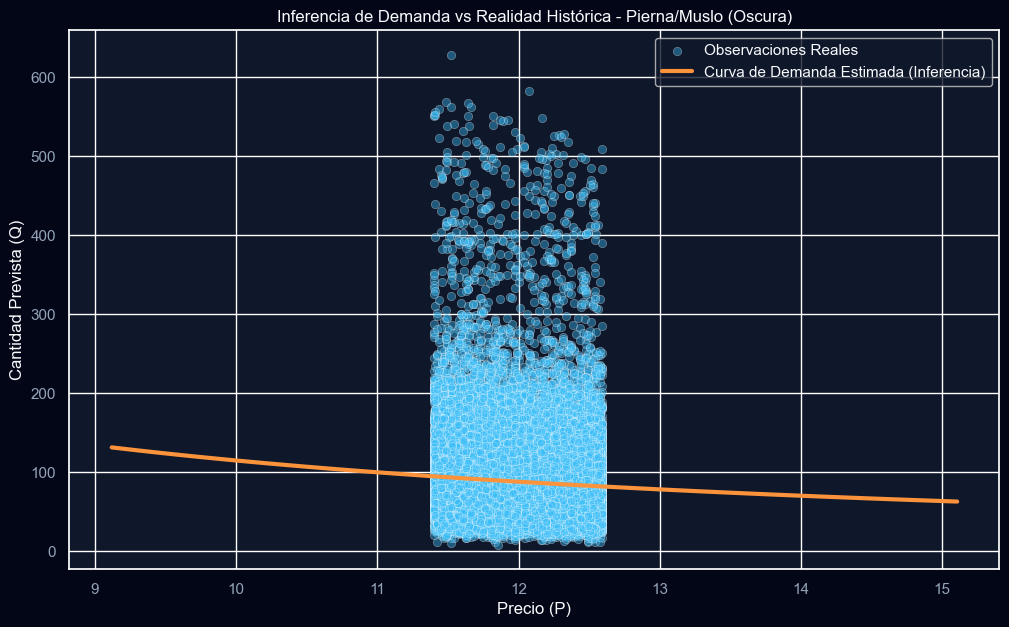

In [69]:
plt.figure(figsize=(12, 7))
# Datos reales
sns.scatterplot(data=df_prod, x='PRECIO', y='CANTIDAD_NORMALIZADA', alpha=0.4, color='#38bdf8', label='Observaciones Reales')
# Curva de inferencia
plt.plot(precios_simulados, cantidades_predichas, color='#fb923c', linewidth=3, label='Curva de Demanda Estimada (Inferencia)')
plt.title(f"Inferencia de Demanda vs Realidad Histórica - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.xlabel('Precio (P)')
plt.ylabel('Cantidad Prevista (Q)')
plt.legend()
plt.show()


**Interpretación:** Esta es exactamente la gráfica central del dashboard. La línea naranja no une puntos; es una función matemática pura basada en los parámetros estructurales $\beta$ hallados, sirviendo como un oráculo de simulación de demanda.


### Optimización del Excedente del Productor (Margen)
Saber la elasticidad no es suficiente. El verdadero valor de negocio es encontrar el precio que maximiza el beneficio monetario (Revenue - Cost).


In [70]:
costo_unitario = df_prod['PRECIO'].mean() * 0.45 # Asumimos 45% del precio promedio histórico

ingresos = precios_simulados * cantidades_predichas
utilidad_neta = (precios_simulados - costo_unitario) * cantidades_predichas

# Encontrar el precio que maximiza la utilidad
indice_max_utilidad = np.argmax(utilidad_neta)
precio_optimo = precios_simulados[indice_max_utilidad]
utilidad_maxima = utilidad_neta[indice_max_utilidad]


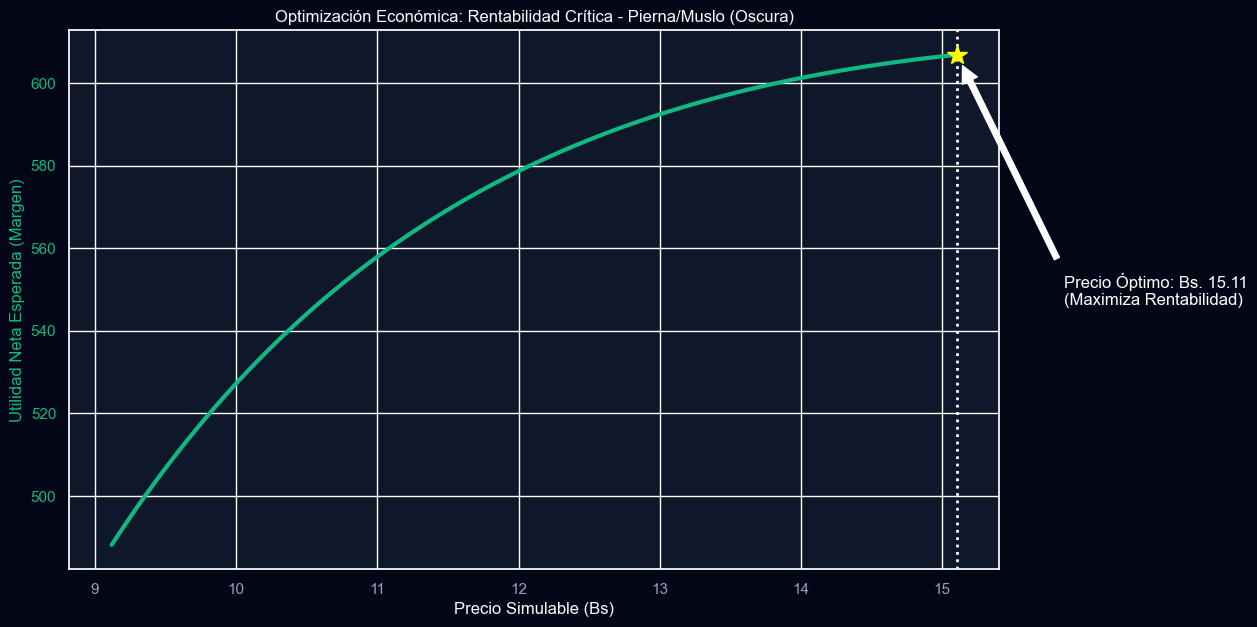

In [71]:
fig, ax1 = plt.subplots(figsize=(12, 7))

color = '#10b981'
ax1.set_xlabel('Precio Simulable (Bs)')
ax1.set_ylabel('Utilidad Neta Esperada (Margen)', color=color)
ax1.plot(precios_simulados, utilidad_neta, color=color, linewidth=3, label='Curva de Margen')
ax1.tick_params(axis='y', labelcolor=color)

# Marcar el punto óptimo
ax1.axvline(precio_optimo, color='w', linestyle=':', linewidth=2)
ax1.plot(precio_optimo, utilidad_maxima, marker='*', markersize=15, color='yellow')
ax1.annotate(f'Precio Óptimo: Bs. {precio_optimo:.2f}\n(Maximiza Rentabilidad)', 
             xy=(precio_optimo, utilidad_maxima), xytext=(precio_optimo*1.05, utilidad_maxima*0.9), 
             arrowprops=dict(facecolor='white', shrink=0.05), color='white')

plt.title(f"Optimización Económica: Rentabilidad Crítica - {df_prod['NOMBRE_PRODUCTO'].iloc[0]}")
plt.show()


**Interpretación de la Optimización:**
*   Si el precio es muy bajo (izq), vendemos mucho, pero el margen unitario es tan bajo que la utilidad total es pobre.
*   Si el precio es muy alto (der), el margen unitario es alto, pero la caída en volumen (por la alta elasticidad detectada) destruye la utilidad total.
*   La curva encuentra el **punto dulce matemático**. El slider en el front-end permite al usuario explorar este trade-off interactivamente.


## 8. Automatización a Escala (Pipeline del Backend)
En producción, el pipeline itera de manera autónoma sobre todo el catálogo.


In [72]:
resultados_catalogo = []

for p_id in df['ID_PRODUCTO_SK'].unique():
    df_temp = df[df['ID_PRODUCTO_SK'] == p_id].copy()
    
    X = sm.add_constant(df_temp['LOG_P'])
    y = df_temp['LOG_Q_NORM']
    
    model = sm.OLS(y, X).fit()
    
    resultados_catalogo.append({
        'ID_PRODUCTO_SK': p_id,
        'NOMBRE_PRODUCTO': df_temp['NOMBRE_PRODUCTO'].iloc[0],
        'ELASTICIDAD': model.params['LOG_P'],
        'INTERCEPTO': model.params['const'],
        'R_SQUARED': model.rsquared
    })

df_resultados = pd.DataFrame(resultados_catalogo)


El backend consolida una matriz maestra de elasticidades.


In [73]:
df_resultados.sort_values(by='ELASTICIDAD')


,ID_PRODUCTO_SK,NOMBRE_PRODUCTO,ELASTICIDAD,INTERCEPTO,R_SQUARED
1,dada4acd662e535dacd7478ff5939dad,Super Mega Combo 12 Piezas,-1.510599,11.705704,0.007474
5,5c36908867d16828ed9d6700e1651492,Pecho/Ala (Blanca),-1.503412,8.329366,0.007369
4,6b6580cb4882e7acba0c8876295714fa,Gaseosa Vaso Regular,-1.493958,7.149849,0.007260
0,a6ad077eb9492ac05c29fa8e421b7a32,Pierna/Muslo (Oscura),-1.467921,8.120642,0.007003
7,5878e5eadaf6ddc18a4e7164ad98f4c9,Combo Familiar 8 Piezas,-1.448881,10.908142,0.006727
2,52f4a8b5c6c149a0b559ee945d07eac5,Combo Personal 2 Piezas,-1.448194,9.134901,0.006856
8,3478035060daf0c7152f24f545ceb65c,Papas Fritas Familiares,-1.429570,8.605706,0.006691
3,9ea0bf838533fe8a5afe1fcf261a1ac5,Gaseosa Botella 2L,-1.385264,8.225355,0.006306
6,43ad74f40746d82036d2e422edb07640,Papas Fritas Normales,-1.384426,7.352405,0.006273


**Interpretación de la Matriz:**
*   **Productos con $\epsilon < -1$**: Son sumamente sensibles al precio. Estrategia sugerida: Cuidado extremo con las alzas.
*   **Productos con $\epsilon \approx -1$**: Tienen elasticidad unitaria. El ingreso se mantiene estable ante cambios de precio.
*   **Productos con $\epsilon > -1$**: Son inelásticos. Estrategia sugerida: Oportunidad para subir precios y mejorar margen operativo con bajo impacto en volumen.

Esta matriz se exporta vía JSON (`elasticity_coefficients.json`) alimentando los selects y la lógica React del cliente web de forma instantánea.
